In [1]:
import sys
sys.path.insert(0, '../lib/')

In [2]:
import os
import pickle
import warnings
import pathlib

import pandas as pd
import numpy as np
import xgboost
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data

In [3]:
pd.options.display.max_rows = 100

# XGBoost baselines for EHRformer tasks

We'll use XGBoost with default parameters on unbinned data for the same tasks and splits as EHRformer

In [4]:
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

In [5]:
ehr_labels = pd.read_csv(common_data.CLINICAL_LABELS, index_col=0)

In [ ]:
EHR_FILE_PATH = common_data.EHRFORMER_BINS
with open(EHR_FILE_PATH, 'rb') as pickle_handle:
    ehr_binned = pickle.load(pickle_handle)

Which features were used for EHRformer?

In [7]:
ehr_features = ehr_binned.columns.to_frame()[0].unique()
sorted(ehr_features)

['ABG_PaCO2',
 'ABG_PaO2',
 'ABG_pH',
 'Age',
 'Albumin',
 'BMI',
 'Bicarbonate',
 'Bilirubin',
 'CRRT_flag',
 'Creatinine',
 'Diastolic_blood_pressure',
 'FiO2',
 'FiO2_changes',
 'GCS_eye_opening',
 'GCS_motor_response',
 'GCS_verbal_response',
 'Gender',
 'Heart_rate',
 'Hemodialysis_flag',
 'Hemoglobin',
 'ICU_stay',
 'Immunocompromised_flag',
 'Intubation_flag',
 'LDH',
 'Lactic_acid',
 'Lung_Compliance',
 'Lymphocytes',
 'Mean_arterial_pressure',
 'Minute_Ventilation',
 'Neutrophils',
 'Norepinephrine_rate',
 'Oxygen_saturation',
 'PEEP',
 'PEEP_changes',
 'PaO2FIO2_ratio',
 'Plateau_Pressure',
 'Platelets',
 'Procalcitonin',
 'RASS_score',
 'Respiratory_rate',
 'Respiratory_rate_changes',
 'Steroid_dose',
 'Systolic_blood_pressure',
 'Temperature',
 'Urine_output',
 'WBC_count',
 'day_of_hospitalization',
 'days_on_ventilator',
 'mean_nat_score_until_yesterday',
 'week_of_hospitalization']

Are they all present in EHR data?

In [8]:
for f in ehr_features:
    if f not in ehr.columns and f not in ehr_labels.columns:
        print(f)

Let's compile the dataframe

In [9]:
xgboost_ehr = ehr.loc[:, ehr.columns.isin(ehr_features)].merge(
    ehr_labels.loc[:, ehr_labels.columns.isin(ehr_features) & ~ehr_labels.columns.isin(ehr.columns)],
    left_index=True,
    right_index=True
)

In [10]:
xgboost_ehr.shape

(15287, 50)

Sort labels by data, to make them the same

In [11]:
ehr_labels = ehr_labels.loc[xgboost_ehr.index]

In [12]:
xgboost_ehr.Gender = pd.Categorical(xgboost_ehr.Gender)

In [13]:
def compute_metrics(data: xgboost.DMatrix, y_probs: np.ndarray) -> dict:
    y_pred = y_probs > 0.5
    y_true = data.get_label()
    n_neg = (y_true == 0).sum()
    n_pos = (y_true == 1).sum()
    auprc_baseline = n_pos / y_true.shape[0]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        auprc = sklearn.metrics.average_precision_score(y_true, y_probs)
        f1_binary = sklearn.metrics.f1_score(y_true, y_pred, average='binary')
        roc_auc = sklearn.metrics.roc_auc_score(y_true, y_probs)
        accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
        recall = sklearn.metrics.recall_score(y_true=y_true, y_pred=y_pred)
        precision = sklearn.metrics.precision_score(y_true=y_true, y_pred=y_pred)

    return {
        'accuracy': accuracy,
        'f1_binary': f1_binary,
        'AUROC': roc_auc,
        'AUPRC': auprc,
        'AUPRC_baseline': auprc_baseline,
        'n_neg': n_neg,
        'n_pos': n_pos,
        'recall': recall,
        'precision': precision,
    }

In [14]:
def get_train_test_data(
        data: pd.DataFrame,
        ehr_labels: pd.DataFrame,
        task_info: common_data.TaskInfo
) -> tuple[xgboost.DMatrix, xgboost.DMatrix]:
    train_idx = ehr_labels[task_info.split_column].eq('train')
    test_idx = ehr_labels[task_info.split_column].eq('test')
    if task_info.pathname == 'any_pathogen':
        y_train = ehr_labels[task_info.column].ne(task_info.column_values[0]).astype(int)[train_idx]
        y_test = ehr_labels[task_info.column].ne(task_info.column_values[0]).astype(int)[test_idx]
    else:
        train_idx &= ehr_labels[task_info.column].isin(task_info.column_values)
        test_idx &= ehr_labels[task_info.column].isin(task_info.column_values)
        y_train = ehr_labels.loc[
            train_idx,
            task_info.column
        ].eq(task_info.column_values[1]).astype(int)
        y_test = ehr_labels.loc[
            test_idx,
            task_info.column
        ].eq(task_info.column_values[1]).astype(int)
    train_data = xgboost.DMatrix(data.loc[train_idx], label=y_train, enable_categorical=True)
    test_data = xgboost.DMatrix(data.loc[test_idx], label=y_test, enable_categorical=True)
    return train_data, test_data

In [15]:
def train_model(data: xgboost.DMatrix) -> xgboost.XGBModel:
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
    }
    return xgboost.train(params, data)

In [ ]:
%%time
base_dir = pathlib.Path('./03_xgboost_models')
result = []
for task in common_data.get_tasks(context='ehrformer') + ['any_pathogen']:
    if task == 'viral_vs_bacterial':
        continue
    # no Healthy EHR data
    if task.startswith('H_'):
        continue
    for split_num in range(1, 5):
        split = f'split_{split_num}'
        if task == 'any_pathogen':
            task_info = common_data.TaskInfo(
                task,
                column='perturbation_groups_2',
                column_values=['NPC'],
                split_column=f'test_split_pg2_split_{split_num}'
            )
        else:
            task_info = common_data.get_task_info(task, split)

        train_data, test_data = get_train_test_data(xgboost_ehr, ehr_labels, task_info)
        model = train_model(train_data)
        probs = model.predict(test_data)
        metrics = compute_metrics(test_data, probs)
        if task == 'any_pathogen':
            metrics['task'] = 'NPC_vs_Any_pathogen'
        elif task_info.column == 'perturbation_groups_2':
            metrics['task'] = '_vs_'.join(task_info.column_values)
        else:
            metrics['task'] = task
        metrics['split'] = task_info.split_column
        result.append(metrics)
        output = base_dir / task / f'{split}.json'
        os.makedirs(output.parent, exist_ok=True)
        model.save_model(output)
result = pd.DataFrame(result)

CPU times: user 17.8 s, sys: 398 ms, total: 18.2 s
Wall time: 1.79 s


In [ ]:
result.to_csv('03_xgboost_results.csv')

In [24]:
import shap

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model.load_model('03_xgboost_models/vap_onset_d7_empirical/split_1.json')
task_info = common_data.get_task_info('vap_onset_d7_empirical', 'split_1')
train_data, test_data = get_train_test_data(xgboost_ehr, ehr_labels, task_info)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

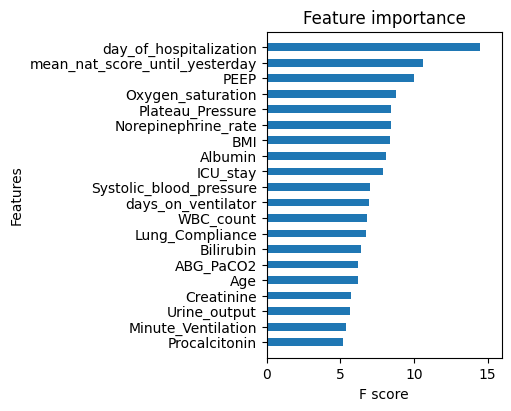

In [26]:
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
xgboost.plot_importance(model, importance_type='gain', height=0.5, ax=ax, show_values=False, grid=False,
                        max_num_features=20)

In [27]:
shap_values = shap.TreeExplainer(model)((pd.DataFrame(
    test_data.get_data().todense(),
    columns=test_data.feature_names
)))

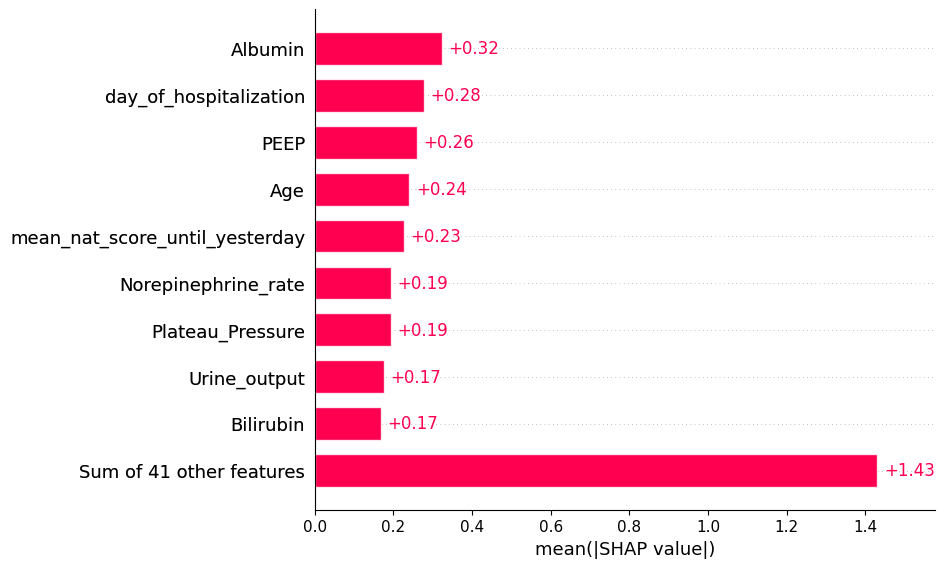

In [28]:
shap.plots.bar(shap_values)

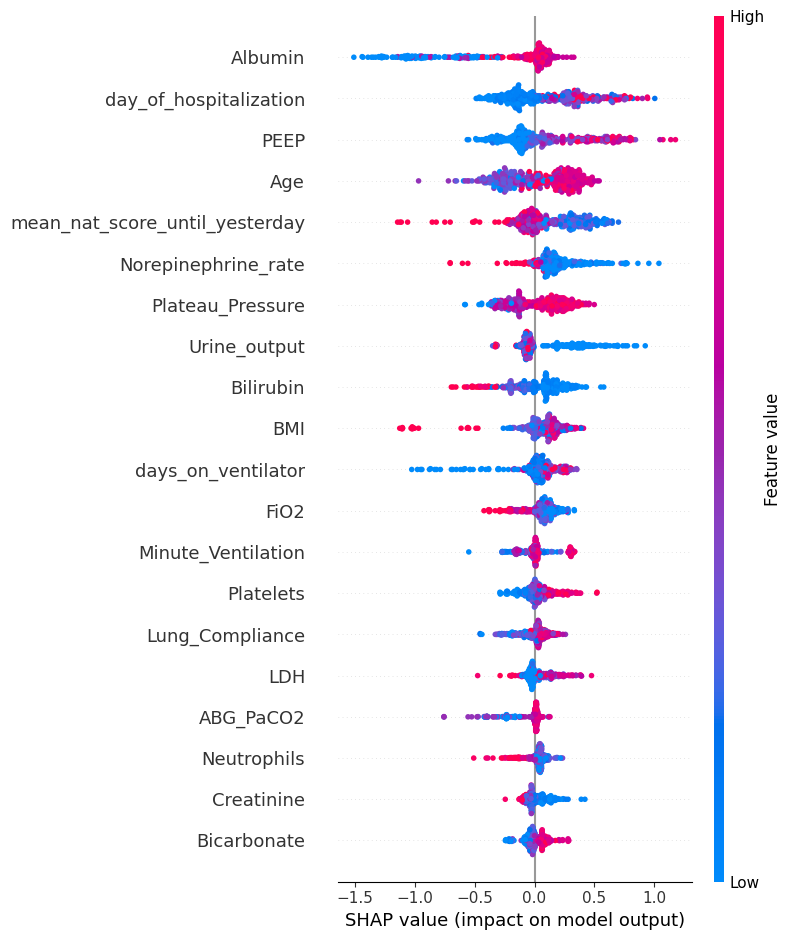

In [29]:
shap.summary_plot(shap_values)

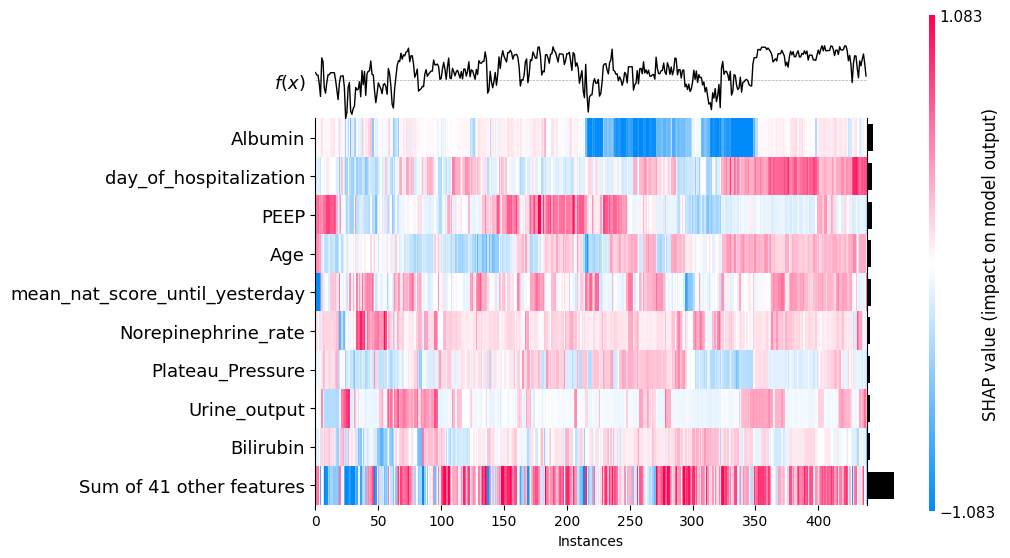

In [30]:
shap.plots.heatmap(shap_values)